In [1]:
# ############################################################
# Level 3 — 여러 변수 상관관계 히트맵 (공개 펭귄 데이터)
# ############################################################
# ------------------------------------------------------------
# [목적] 도구 불러오기
# ------------------------------------------------------------
import pandas as pd                               # 표(CSV) 다루기
import seaborn as sns                             # 예쁜 그래프 도구 (히트맵)
import matplotlib.pyplot as plt                   # 그래프 그리기
%matplotlib inline

In [2]:
# ------------------------------------------------------------
# [데이터 살펴보기 · EDA] 펭귄 데이터 불러오고 살펴보기
#   · 펭귄 개체 × 부리 길이·부리 깊이·지느러미 길이·몸무게·종·성별 등
# ------------------------------------------------------------
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
df = pd.read_csv(url).dropna()                    # 공개 URL, 빈 값 행 제거 (dropna=빈칸 있는 행 버리기)
print('데이터 크기(행, 열):', df.shape)           # 크기 확인 (개체 수 × 열 수)
df.head()                                          # 앞 5줄 미리보기 (어떤 컬럼이 있나)

데이터 크기(행, 열): (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [3]:
# ------------------------------------------------------------
# [목적] 숫자 열만 골라 상관계수 표 만들기 (상관은 숫자끼리만)
# ------------------------------------------------------------
num = df.select_dtypes(include='number')          # 숫자 열만 (종·성별 같은 글자 열은 제외)
corr = num.corr()                                 # 변수쌍 상관계수 표 (-1~1, 함께 움직이는 정도)
corr.round(2)                                      # 표 확인 (숫자로 먼저 보기)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.23,0.65,0.59
bill_depth_mm,-0.23,1.00,-0.58,-0.47
flipper_length_mm,0.65,-0.58,1.00,0.87
body_mass_g,0.59,-0.47,0.87,1.00


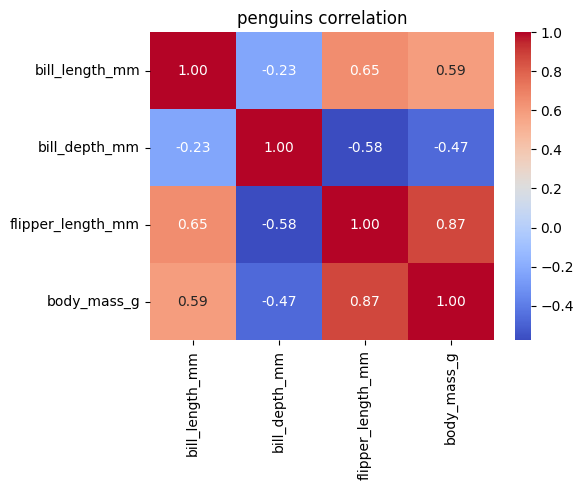

In [4]:
# ------------------------------------------------------------
# [목적] 상관계수를 색+숫자 히트맵으로 시각화
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')  # 색=진하기, annot=숫자표시 (붉을수록 +, 파랄수록 -)
plt.title('penguins correlation')                 # 제목 (한글은 깨질 수 있어 영문)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# [결과 해석]
#  · 부리 길이(bill_length)와 지느러미 길이(flipper_length), 몸무게(body_mass)가 서로 강한 양의 상관
#      -> 한 값이 크면 다른 값도 큰 경향 (진한 붉은색)
#  · 부리 깊이(bill_depth)는 다른 값들과 음의 상관 (파란색) -> 반대로 움직이는 경향
#  · 히트맵 하나로 '어떤 변수끼리 붙어 다니는지'를 한눈에 파악
# ============================================================